## **We are going to get insights from this cleaned dataset**



#### **Possible assumptions and questions which we will ask and verify after analysing the dataset.**

* Does the economic status of the family/ spouse living outside/ family member suffering from chronic disease/ covid case in the family/ affected the mental health of the respondent?
* Does the change in economic status of the family, affected the education of childrens?
* How many of the respondents were living outside their hometown during covid?
* Which age group suffered the most and what is the probable factor?
* How many families suffered from socio-economic decline but still managed to continue the education of the childs?
* How did the covid era contributed in leisure time?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
mh = pd.read_csv('/content/adult mental health in indian metro cities 2001-2021 (cleaned).csv')

In [2]:
# Install itables
%pip install itables
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)
mh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 38.4 MB/s eta 0:00:00


Loading ITables v2.7.3 from the internet... (need help?)


In [ ]:
len(mh)

978

In [ ]:
mh['age'].describe()

Loading ITables v2.7.0 from the internet... (need help?)


In [3]:
sns.set()

<Axes: xlabel='age', ylabel='Count'>

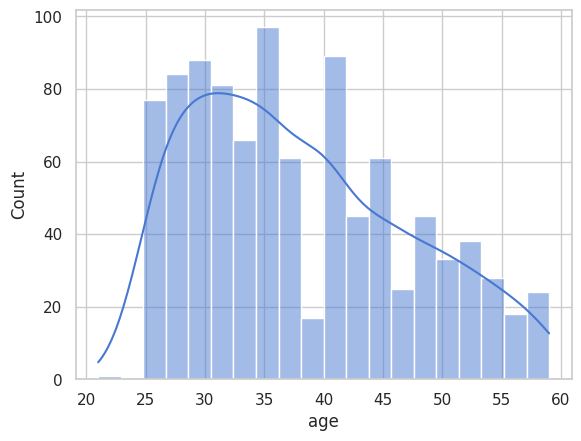

In [ ]:
sns.histplot(mh['age'], bins=20, kde=True)

In [ ]:
mh['age'].skew()

np.float64(0.5023728928696087)

* If skewness is close to 0 -> approximately normally distributed
* If it is close to 1 -> +ve-ly skewed
* If it is close to -1 -> -ve-ly skewed

####**Age**
* The age data is +vely skewed with a value of 0.5
* Numbebr of outliers are near to zero
* Most of the respondents age lies between 25-50
* No missing values

In [4]:
sns.set_theme(style="whitegrid", palette="muted")

### **Socio-Demographic Characteristics of Respondents:**

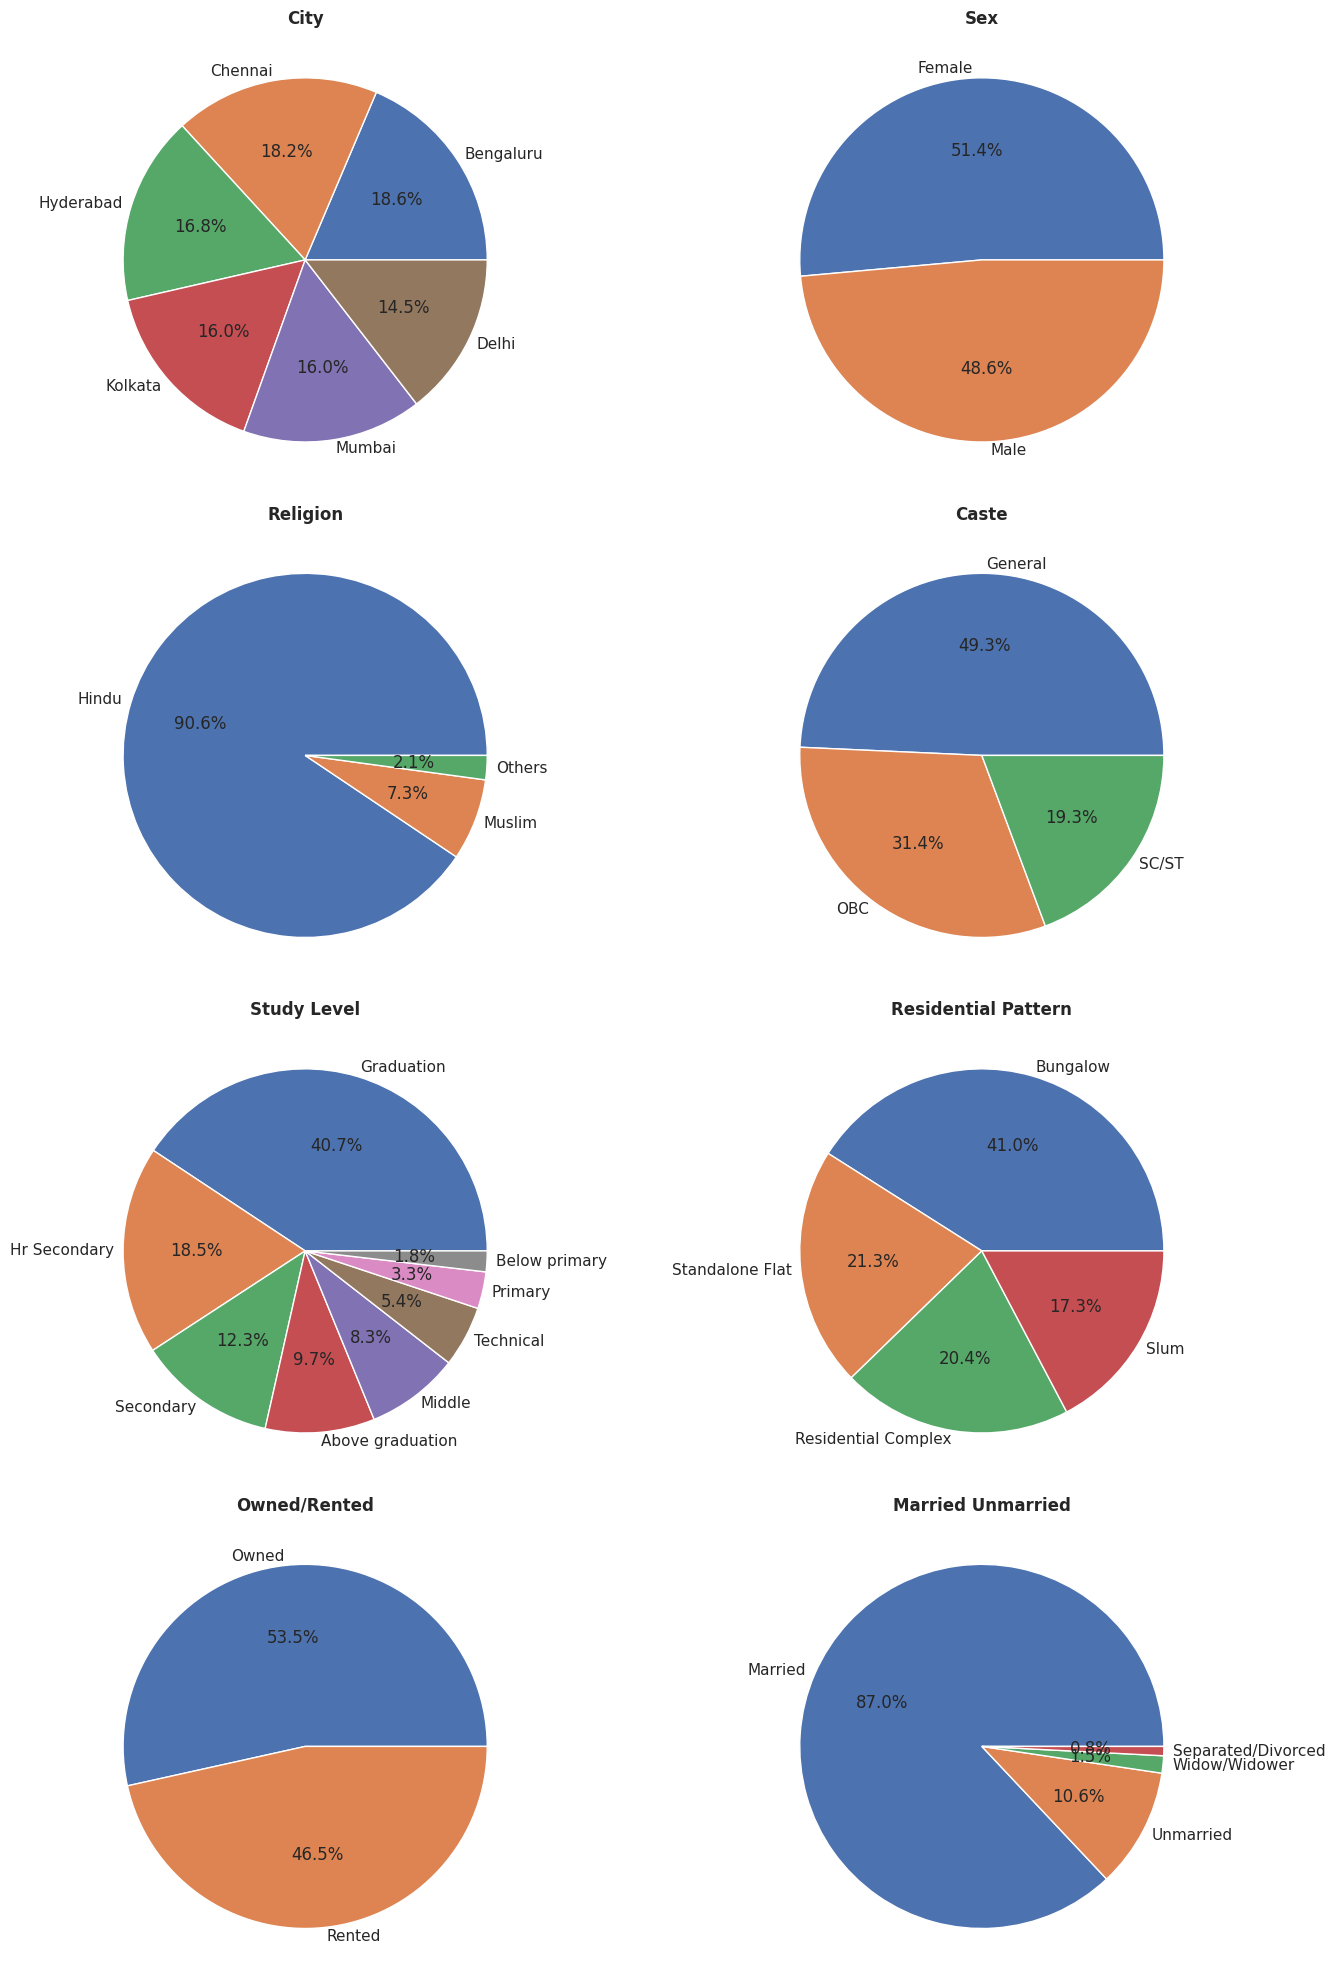

In [ ]:
cols = ['city','sex','religion','caste','study_level',
        'residential_pattern','owned/rented','married_unmarried']
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14,20))
axes = axes.flatten()
for ax, i in zip(axes, cols):
    mh[i].value_counts().plot.pie(autopct='%1.1f%%', labeldistance=1.05, ax=ax)
    ax.set_title(i.replace('_',' ').title(),fontweight='bold')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

###**Occupation Counts:**

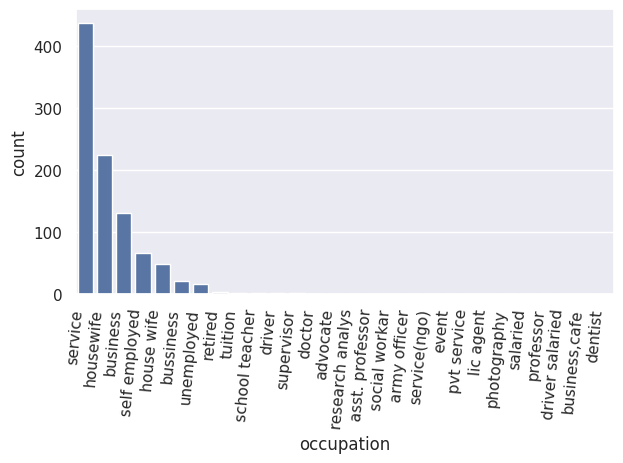

In [ ]:
occupation_counts = mh['occupation'].value_counts().reset_index()
sns.barplot(x='occupation', y='count', data=occupation_counts)
plt.xticks(rotation=85, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
mh['occupation'].describe()

Loading ITables v2.7.0 from the internet... (need help?)


In [ ]:
mh


Loading ITables v2.7.0 from the internet... (need help?)


#### Percentage =  (Row Total)/(Cell Count​) × 100

###**Respondent's economic condition over both phase:**

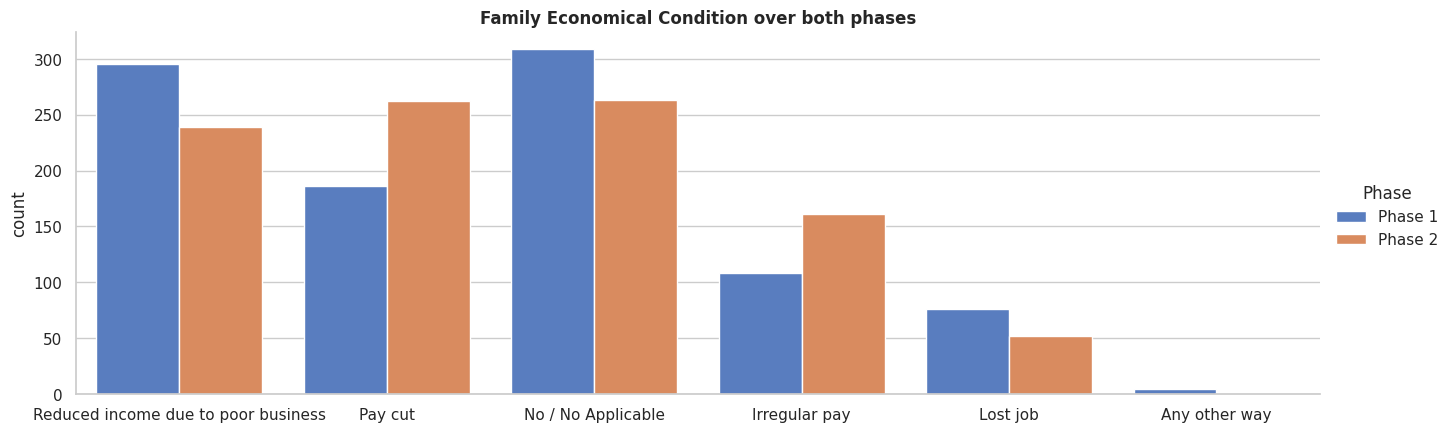

In [ ]:
mh_melt = mh.melt(value_vars=['family_economicaly_affected T1','family_economicaly_affected T2'], var_name='Phase', value_name='values')

mh_melt['Phase'] = mh_melt['Phase'].replace({'family_economicaly_affected T1':'Phase 1', 'family_economicaly_affected T2':'Phase 2'})
sns.catplot(data=mh_melt, x='values', hue='Phase', kind='count', height=4.5, aspect=3)
plt.title('Family Economical Condition over both phases', fontweight='bold')
plt.xlabel('')   # remove bottom label
plt.show()

* This shows that in Most families economic status did not alter
* Families who faced a reduction in income due to poor buiness comes in the second

**Asssumption->** There could be a possibility that those families who lost job, suffered from a severe mental distress

Although we will make the severity comparison for each scenario

### **Economic status count over both phase:**

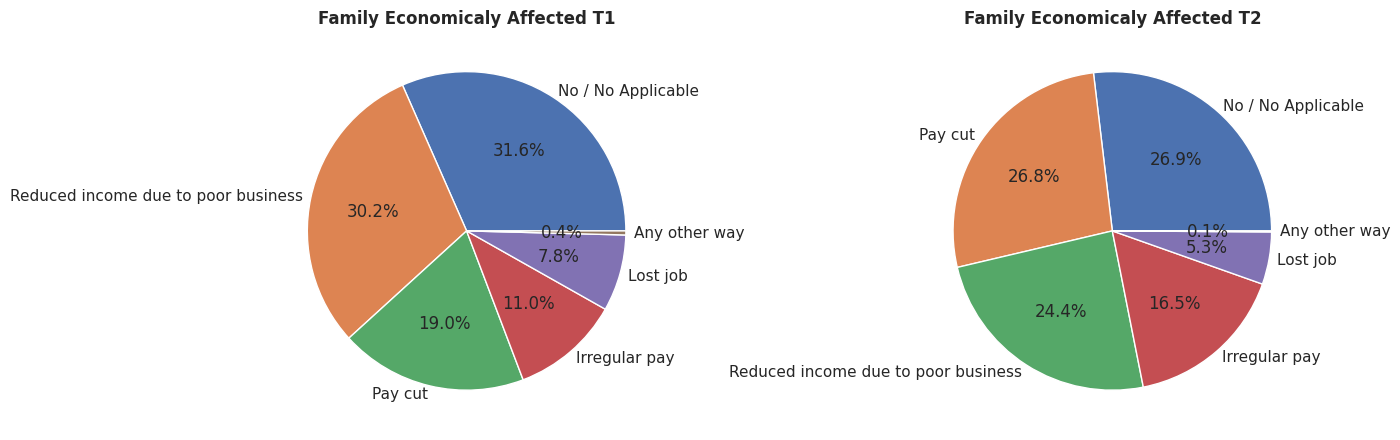

In [ ]:
cols = ['family_economicaly_affected T1','family_economicaly_affected T2']
fig, axes = plt.subplots(ncols=2, figsize=(14,14))
axes = axes.flatten()
for ax, i in zip(axes, cols):
    mh[i].value_counts().plot.pie(autopct='%1.1f%%', labeldistance=1.05, ax=ax)
    ax.set_title(i.replace('_',' ').title(),fontweight='bold')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

### **Economic status V/s Depression**

In [ ]:
order1 = ['Normal','Mild','Moderate','Severe','Extremely severe']
order2 = ['Any other way', 'Lost job', 'Irregular pay', 'Pay cut', 'Reduced income due to poor business', 'No / No Applicable']
table_eco_vs_depT1 = pd.crosstab(mh['depression_level T1'], mh['family_economicaly_affected T1']).reindex(order1).reindex(order2, axis=1)
table_eco_vs_depT1

Loading ITables v2.7.1 from the internet... (need help?)


In [ ]:
percent_table_eco_vs_depT1 = table_eco_vs_depT1.div(table_eco_vs_depT1.sum(axis=1), axis=0) * 100
percent_table_eco_vs_depT1

Loading ITables v2.7.1 from the internet... (need help?)


In [ ]:
melted_t1 = table_eco_vs_depT1.reset_index().melt(id_vars='depression_level T1', value_vars=order2, value_name='Count')
melted_t1

Loading ITables v2.7.1 from the internet... (need help?)


In [ ]:
percent_melted_t1 = percent_table_eco_vs_depT1.reset_index().melt(id_vars='depression_level T1', value_vars=order2, value_name='Count in Percentage T1')
percent_melted_t1

Loading ITables v2.7.1 from the internet... (need help?)


In [ ]:
table_eco_vs_depT2 = pd.crosstab(mh['depression_level T2'], mh['family_economicaly_affected T2']).reindex(order1).reindex(order2, axis=1)
table_eco_vs_depT2

Loading ITables v2.7.1 from the internet... (need help?)


In [ ]:
percent_table_eco_vs_depT2 = table_eco_vs_depT2.div(table_eco_vs_depT2.sum(axis=1), axis=0) * 100
percent_table_eco_vs_depT2

Loading ITables v2.7.1 from the internet... (need help?)


In [ ]:
percent_melted_t2 = percent_table_eco_vs_depT2.reset_index().melt(id_vars='depression_level T2', value_vars=order2, value_name='Count in Percentage T2')
percent_melted_t2

Loading ITables v2.7.1 from the internet... (need help?)


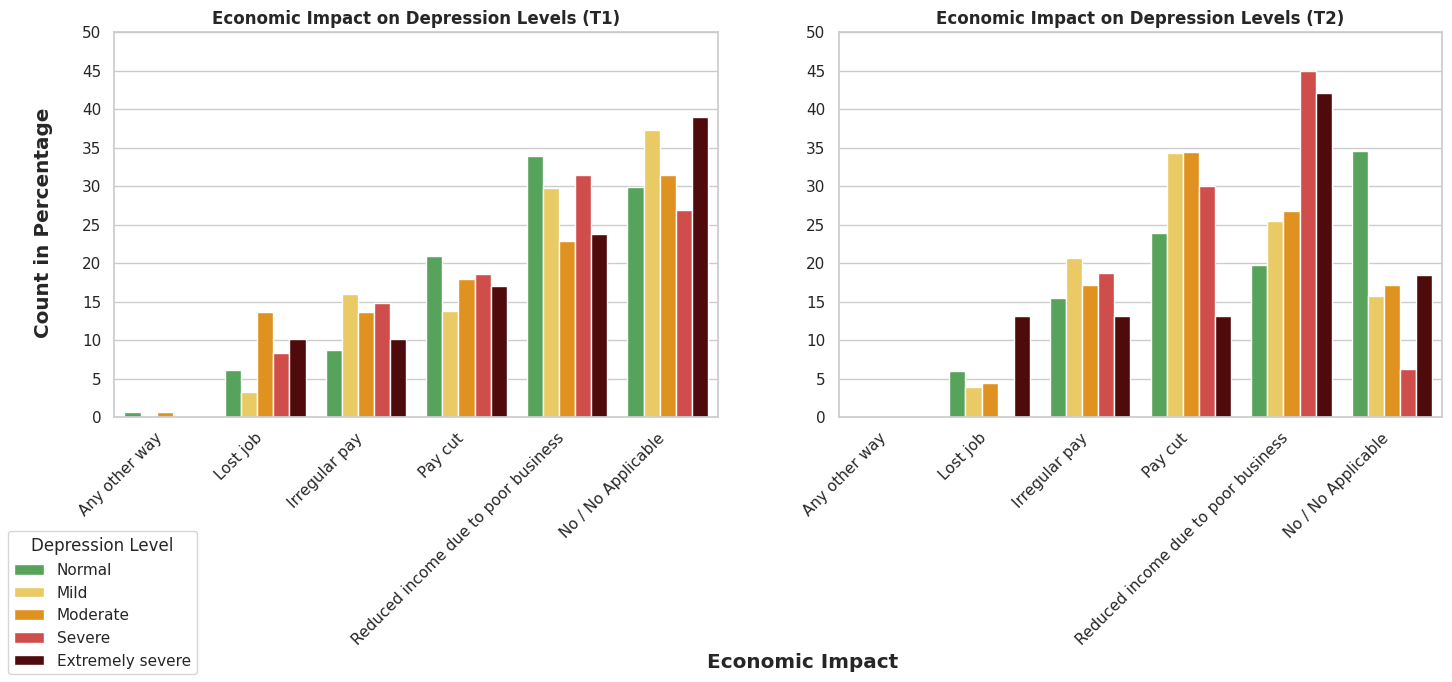

In [ ]:
severity_order = ['Normal','Mild','Moderate','Severe','Extremely severe']
palette = {
    'Normal': '#4caf50',            # green
    'Mild': '#ffd54f',              # yellow
    'Moderate': '#ff9800',          # orange
    'Severe': '#e53935',            # red
    'Extremely severe': '#5a0000'   # maroon
}

fig,axes = plt.subplots(1,2, figsize=(16,5))

sns.barplot(data=percent_melted_t1, x='family_economicaly_affected T1',  y='Count in Percentage T1', hue='depression_level T1', palette=palette, ax=axes[0])
axes[0].set_title("Economic Impact on Depression Levels (T1)", fontweight='bold')
axes[0].set_yticks(np.linspace(0, 50, 11))

sns.barplot(data=percent_melted_t2, x='family_economicaly_affected T2',  y='Count in Percentage T2', hue='depression_level T2', palette=palette, ax=axes[1])
axes[1].set_title("Economic Impact on Depression Levels (T2)", fontweight='bold')
axes[1].set_yticks(np.linspace(0, 50, 11))

fig.supxlabel("Economic Impact", fontweight='bold', y=-0.40)   # centered
fig.supylabel("Count in Percentage", fontweight='bold')        # global labels
fig.subplots_adjust(left=0.07)                                 # subplots left alignment

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')     # removes the individual x & y label
    ax.set_ylabel('')
    for label in ax.get_xticklabels():
      label.set_horizontalalignment('right')

# getting the information about the legend
handles, labels = axes[0].get_legend_handles_labels()

# remove legends from subplots
axes[0].legend_.remove()
axes[1].legend_.remove()

# creating global legend
fig.legend(handles, labels, title="Depression Level", loc="lower left")

plt.show()

**Conclusion:**
  * It shows that overall number of extremely severe cases decreased over phase 2 except those whose income reduced in business.
  * Almost 45% of the respondents faced severe depression over phase 2 whose family business reduced.
  * Interestingly respondents whose families were not affected economically, most of them faced depression to some extent in phase 1.
  * Respondents whose family faced pay cut over phase 2, many of them suffered from depression to some level.


### **Economic status V/s Anxiety**

In [ ]:
order1 = ['Normal','Mild','Moderate','Severe','Extremely severe']
order2 = ['Any other way', 'Lost job', 'Irregular pay', 'Pay cut', 'Reduced income due to poor business', 'No / No Applicable']

table_eco_vs_anxT1 = pd.crosstab(mh['anxiety_level T1'], mh['family_economicaly_affected T1']).reindex(order1).reindex(order2, axis=1)
percent_table_eco_vs_anxT1 = table_eco_vs_anxT1.div(table_eco_vs_anxT1.sum(axis=1), axis=0) * 100
percent_melted_t1 = percent_table_eco_vs_anxT1.reset_index().melt(id_vars='anxiety_level T1', value_vars=order2, value_name='Count in Percentage')

table_eco_vs_anxT2 = pd.crosstab(mh['anxiety_level T2'], mh['family_economicaly_affected T2']).reindex(order1).reindex(order2, axis=1)
percent_table_eco_vs_anxT2 = table_eco_vs_anxT2.div(table_eco_vs_anxT2.sum(axis=1), axis=0) * 100
percent_melted_t2 = percent_table_eco_vs_anxT2.reset_index().melt(id_vars='anxiety_level T2', value_vars=order2, value_name='Count in Percentage')

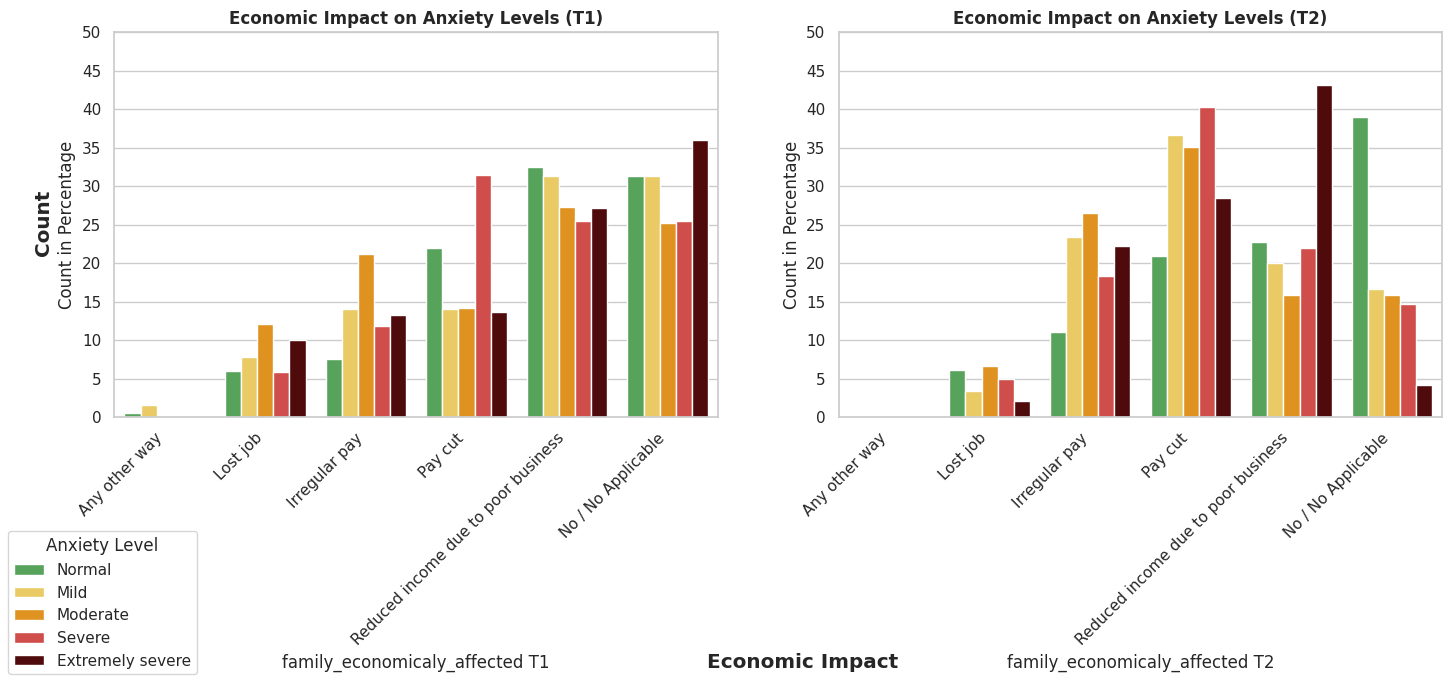

In [ ]:
severity_order = ['Normal','Mild','Moderate','Severe','Extremely severe']
palette = {
    'Normal': '#4caf50',            # green
    'Mild': '#ffd54f',              # yellow
    'Moderate': '#ff9800',          # orange
    'Severe': '#e53935',            # red
    'Extremely severe': '#5a0000'   # maroon
}

fig,axes = plt.subplots(1,2, figsize=(16,5))

sns.barplot(data=percent_melted_t1, x='family_economicaly_affected T1',  y='Count in Percentage', hue='anxiety_level T1', palette=palette, ax=axes[0])
axes[0].set_title("Economic Impact on Anxiety Levels (T1)", fontweight='bold')
axes[0].set_yticks(np.linspace(0, 50, 11))

sns.barplot(data=percent_melted_t2, x='family_economicaly_affected T2',  y='Count in Percentage', hue='anxiety_level T2', palette=palette, ax=axes[1])
axes[1].set_title("Economic Impact on Anxiety Levels (T2)", fontweight='bold')
axes[1].set_yticks(np.linspace(0, 50, 11))

fig.supxlabel("Economic Impact", fontweight='bold', y=-0.40)   # centered
fig.supylabel("Count in Percentage", fontweight='bold')
fig.subplots_adjust(left=0.07)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for label in ax.get_xticklabels():
      label.set_horizontalalignment('right')

# getting the information about the legend
handles, labels = axes[0].get_legend_handles_labels()

# remove legends from subplots
axes[0].legend_.remove()
axes[1].legend_.remove()

# creating global legend
fig.legend(handles, labels, title="Anxiety Level", loc="lower left")

plt.show()

**Conclusion:**
* Extreme levels of anxiety were predominantly observed among individuals whose families either suffered business losses or experienced no change in their economic condition during Phase 1.
* A majority of the respondents ~ 44% suffered from severe anxiety whose families suffered business losses during phase 2.
* Number of severe cases of anxiety observed more in those whose families experienced pay cut.
* Surprisingly very few cases of anxiety were reported among individuals whose families experienced job loss in both phases.


### **Economic status V/s Stress**

In [ ]:
order1 = ['Normal','Mild','Moderate','Severe','Extremely severe']
order2 = ['Any other way', 'Lost job', 'Irregular pay', 'Pay cut', 'Reduced income due to poor business', 'No / No Applicable']

table_eco_vs_strT1 = pd.crosstab(mh['stress_level T1'], mh['family_economicaly_affected T1']).reindex(order1).reindex(order2, axis=1)
percent_table_eco_vs_strT1 = table_eco_vs_strT1.div(table_eco_vs_strT1.sum(axis=1), axis=0) * 100
percent_melted_t1 = percent_table_eco_vs_strT1.reset_index().melt(id_vars='stress_level T1', value_vars=order2, value_name='Count in Percentage')

table_eco_vs_strT2 = pd.crosstab(mh['stress_level T2'], mh['family_economicaly_affected T2']).reindex(order1).reindex(order2, axis=1)
percent_table_eco_vs_strT2 = table_eco_vs_strT2.div(table_eco_vs_strT2.sum(axis=1), axis=0) * 100
percent_melted_t2 = percent_table_eco_vs_strT2.reset_index().melt(id_vars='stress_level T2', value_vars=order2, value_name='Count in Percentage')

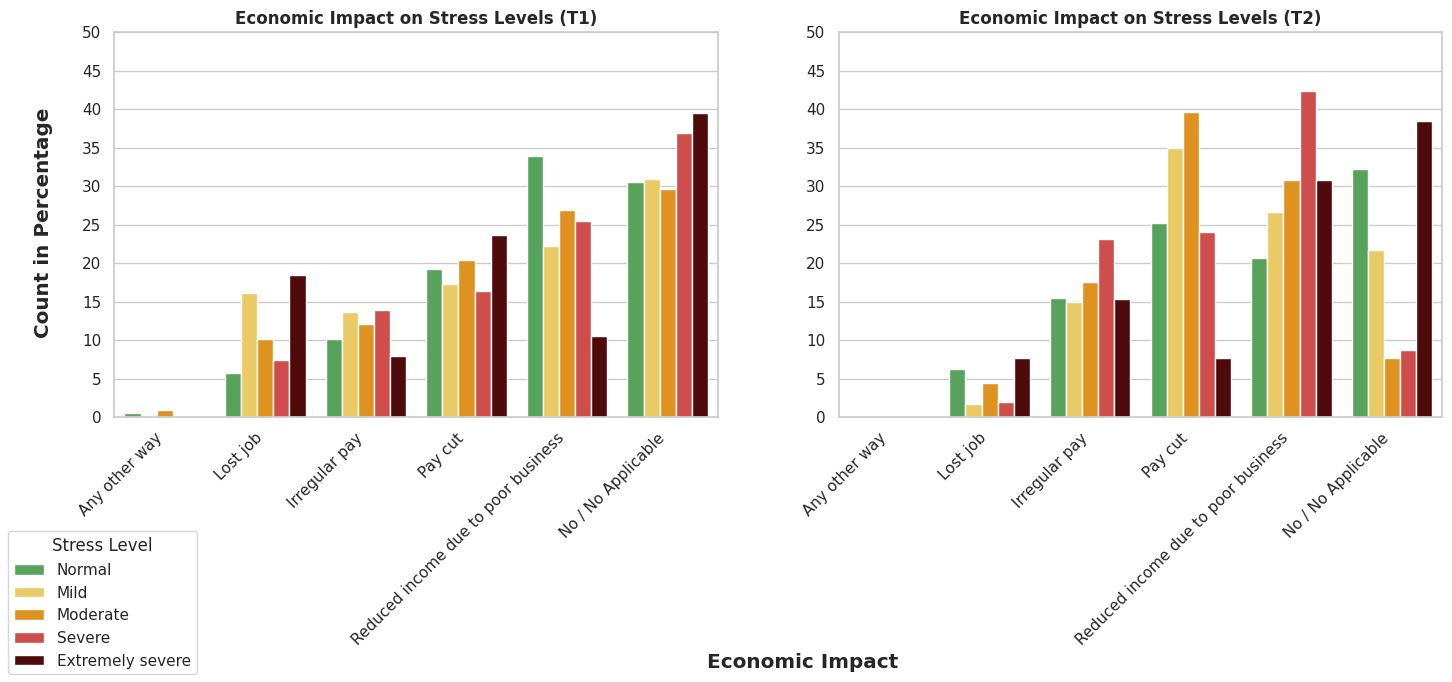

In [ ]:
severity_order = ['Normal','Mild','Moderate','Severe','Extremely severe']
palette = {
    'Normal': '#4caf50',            # green
    'Mild': '#ffd54f',              # yellow
    'Moderate': '#ff9800',          # orange
    'Severe': '#e53935',            # red
    'Extremely severe': '#5a0000'   # maroon
}

fig,axes = plt.subplots(1,2, figsize=(16,5))

sns.barplot(data=percent_melted_t1, x='family_economicaly_affected T1',  y='Count in Percentage', hue='stress_level T1', palette=palette, ax=axes[0])
axes[0].set_title("Economic Impact on Stress Levels (T1)", fontweight='bold')
axes[0].set_yticks(np.linspace(0, 50, 11))

sns.barplot(data=percent_melted_t2, x='family_economicaly_affected T2',  y='Count in Percentage', hue='stress_level T2', palette=palette, ax=axes[1])
axes[1].set_title("Economic Impact on Stress Levels (T2)", fontweight='bold')
axes[1].set_yticks(np.linspace(0, 50, 11))

fig.supxlabel("Economic Impact", fontweight='bold', y=-0.40)   # centered
fig.supylabel("Count in Percentage", fontweight='bold')
fig.subplots_adjust(left=0.07)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for label in ax.get_xticklabels():
      label.set_horizontalalignment('right')

# getting the information about the legend
handles, labels = axes[0].get_legend_handles_labels()

# remove legends from subplots
axes[0].legend_.remove()
axes[1].legend_.remove()

# creating global legend
fig.legend(handles, labels, title="Stress Level", loc="lower left")

plt.show()

**Conclusion:**
* Extreme levels of stress were predominantly observed among individuals whose families experienced no change in their economic condition during both phase.
* A majority of the respondents suffered from either severe or extremely severe anxiety whose families suffered business losses during phase 2.
* Most of the individuals whose families experienced a pay cut suffered from moderate level of anxiety.
* A decline in the cases of stress were observed among individuals whose families experienced job loss in phase 2.

###**Respondent's monthly expenditure over both phase:**

In [ ]:
mh['monthly_expenditure T1'].max()
mh['monthly_expenditure T2'].max()

200000.0

In [ ]:
bins = np.linspace(0, 250000, 26)
bins

array([     0.,  10000.,  20000.,  30000.,  40000.,  50000.,  60000.,
        70000.,  80000.,  90000., 100000., 110000., 120000., 130000.,
       140000., 150000., 160000., 170000., 180000., 190000., 200000.,
       210000., 220000., 230000., 240000., 250000.])

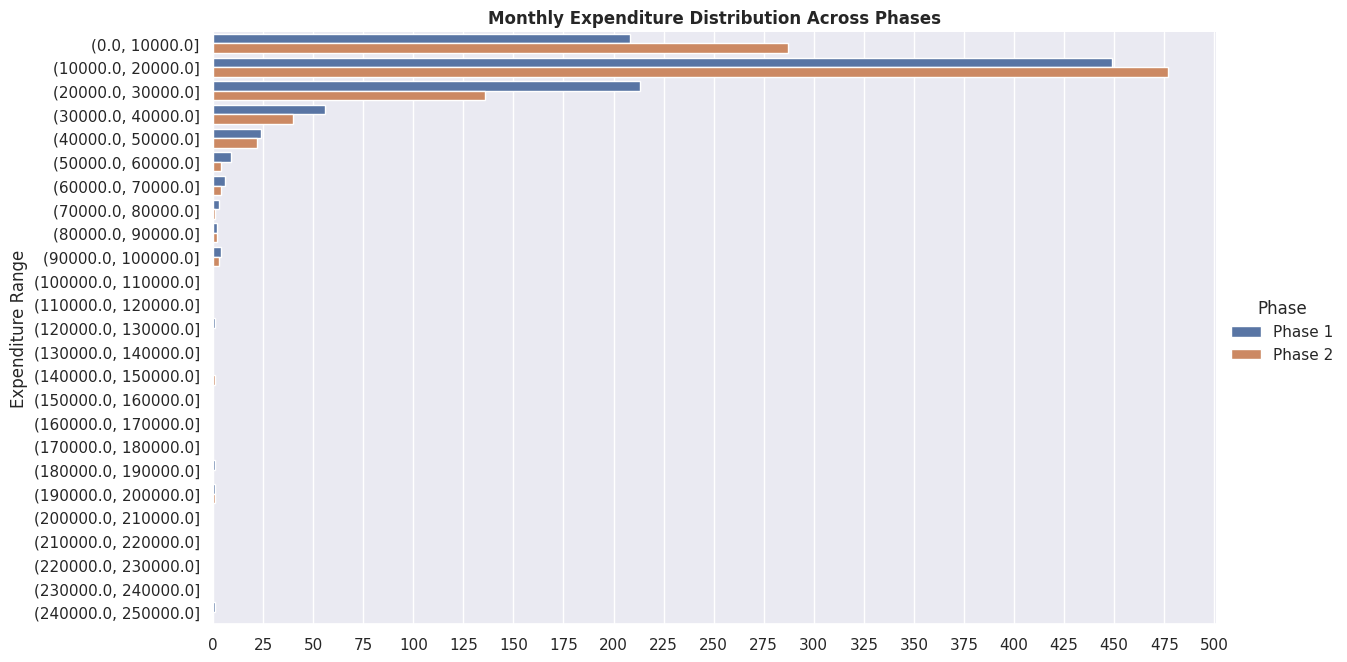

In [ ]:
mh_melt = mh.melt(value_vars=['monthly_expenditure T1','monthly_expenditure T2'], var_name='Phase', value_name='Expenditure')

mh_melt['Phase'] = mh_melt['Phase'].replace({'monthly_expenditure T1':'Phase 1', 'monthly_expenditure T2':'Phase 2'})
mh_melt['Expenditure Range'] = pd.cut(mh_melt['Expenditure'], bins=bins)

sns.catplot(data=mh_melt, kind='count', y='Expenditure Range', hue='Phase', height=6.8, aspect=1.85)
plt.title('Monthly Expenditure Distribution Across Phases', fontweight='bold')
plt.xticks(np.linspace(0, 500, 21))
plt.xlabel('')
plt.show()

#### **Conclusion:**
* In most of the cases monthly expenditure increased in families with lower income ranging from 0-20000 rs.
* The results indicate an increase in the number of families in the lower expenditure groups (0-10k, 10k-20k) from Phase 1 to Phase 2.
* It also indicates a decrease in the number of families in the mid-expenditure groups (20k-30k, 30k-40k) from phase 1 to phase 2.
* Rate of expenditure did not made a huge change in the families with comparitively higher income.

It is possible that families reduced their expenditure due to fear of being affected by COVID-19 again. Statistical evidence suggests that most families may have adopted greater saving behaviour, which is consistent with our finding that a higher proportion of households fall within the lower and medium expenditure ranges.

###**Change of Occupation V/s Change of Occupation of main member:**

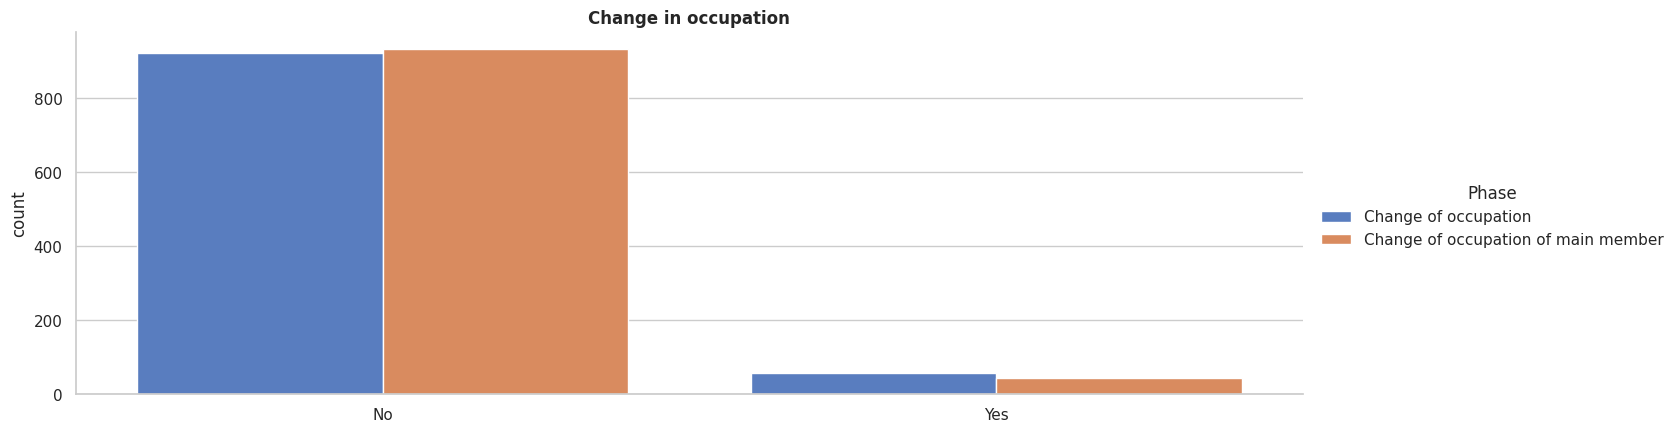

In [ ]:
mh_melt = mh.melt(value_vars=['change_of_occ','change_of_occ_mainmember'], var_name='Phase', value_name='Occupation')

mh_melt['Phase'] = mh_melt['Phase'].replace({'change_of_occ':'Change of occupation', 'change_of_occ_mainmember':'Change of occupation of main member'})
sns.catplot(data=mh_melt, x='Occupation', hue='Phase', kind='count', height=4.5, aspect=3)
plt.title('Change in occupation', fontweight='bold')
plt.xlabel('')
plt.show()

####
This comparison represents that in majority of the families, respondent's occupation did not change and occupation did not change for the main members either.
* This shows that the respondents are in fact the main members of the family in almost every cases.

###**Respondent's children education status over both phase:**

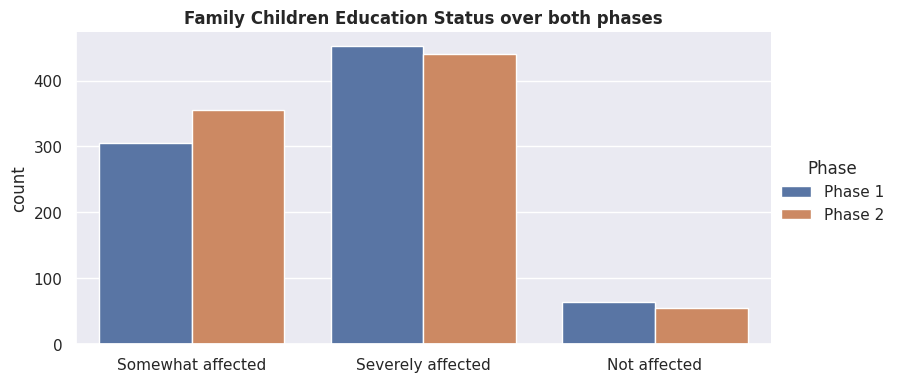

In [ ]:
mh_melt = mh.melt(value_vars=['education_of_children T1','education_of_children T2'], var_name='Phase', value_name='Education')
mh_melt['Phase'] = mh_melt['Phase'].replace({'education_of_children T1':'Phase 1', 'education_of_children T2':'Phase 2'})
sns.catplot(data=mh_melt, x='Education', hue='Phase', kind='count', height=4, aspect=2)
plt.title('Family Children Education Status over both phases', fontweight='bold')
plt.xlabel('')   # remove bottom label
plt.show()

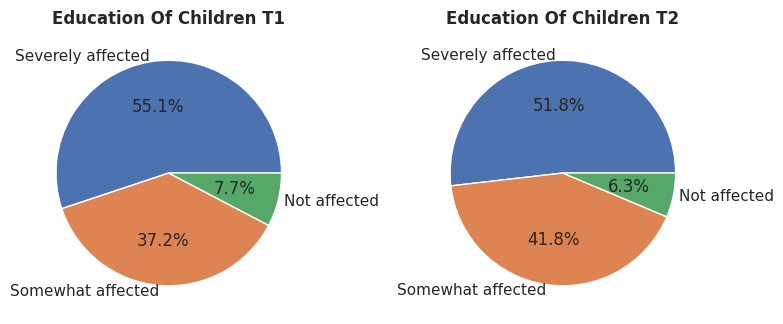

In [ ]:
cols = ['education_of_children T1','education_of_children T2']
fig, axes = plt.subplots(ncols=2, figsize=(8,8))
axes = axes.flatten()
for ax, i in zip(axes, cols):
    mh[i].value_counts().plot.pie(autopct='%1.1f%%', labeldistance=1.05, ax=ax)
    ax.set_title(i.replace('_',' ').title(),fontweight='bold')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

####
This shows that in most of the families, education of childrens affected.

**Asssumption->** There could be a possibility that education of childrens affected in those famlies who were financially weak or suffered a economic decline.

Also it may be possible that this factor contributed in the mental health of the respondents

##**Does the worsening of child education status made any impact on respondent's mental health?**  

###**Education of children V/s Depression Level:**  

In [ ]:
mh

Loading ITables v2.7.1 from the internet... (need help?)


In [ ]:
order1 = ['Normal','Mild','Moderate','Severe','Extremely severe']
order2 = ['Not affected', 'Somewhat affected', 'Severely affected']

table_edu_vs_depT1 = pd.crosstab(mh['depression_level T1'], mh['education_of_children T1']).reindex(order1).reindex(order2, axis=1)
percent_table_edu_vs_depT1 = table_edu_vs_depT1.div(table_edu_vs_depT1.sum(axis=1), axis=0) * 100
percent_melted_t1 = percent_table_edu_vs_depT1.reset_index().melt(id_vars='depression_level T1', value_vars=order2, value_name='Count in Percentage')

table_edu_vs_depT2 = pd.crosstab(mh['depression_level T2'], mh['education_of_children T2']).reindex(order1).reindex(order2, axis=1)
percent_table_edu_vs_depT2 = table_edu_vs_depT2.div(table_edu_vs_depT2.sum(axis=1), axis=0) * 100
percent_melted_t2 = percent_table_edu_vs_depT2.reset_index().melt(id_vars='depression_level T2', value_vars=order2, value_name='Count in Percentage')

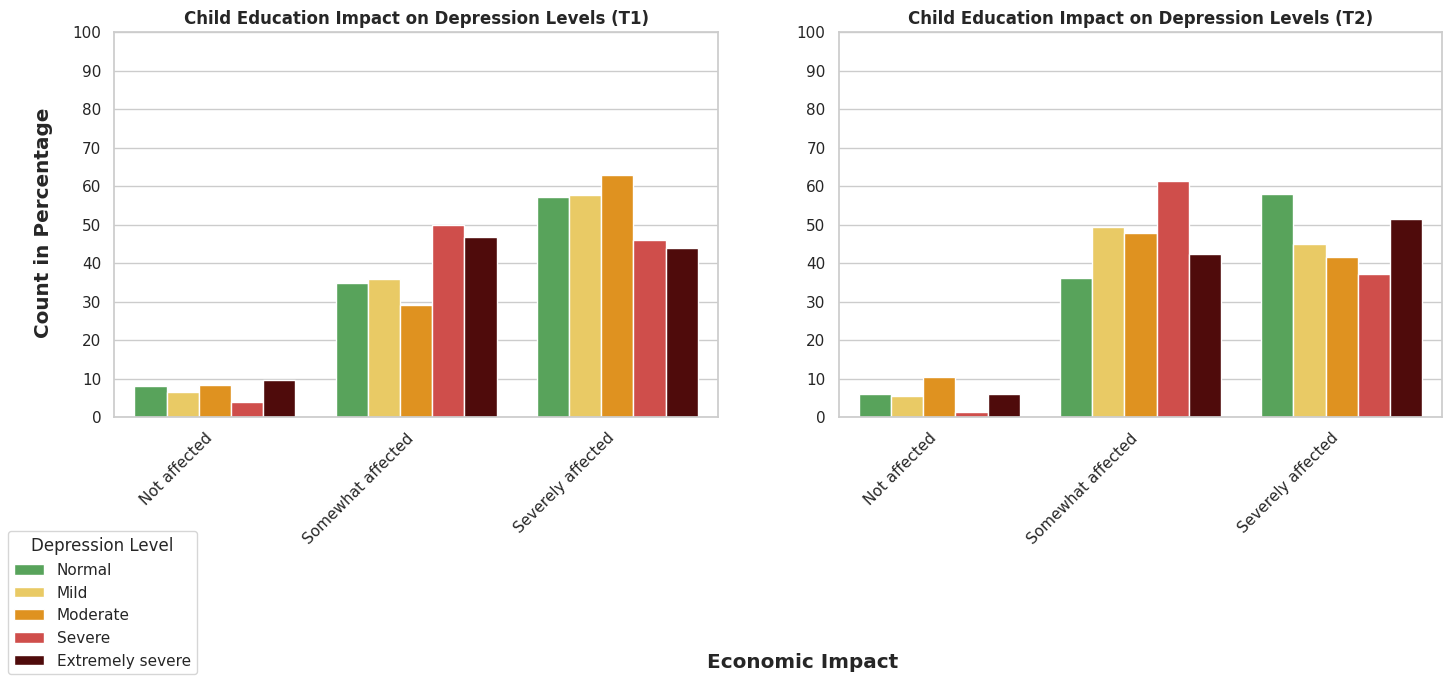

In [ ]:
severity_order = ['Normal','Mild','Moderate','Severe','Extremely severe']
palette = {
    'Normal': '#4caf50',            # green
    'Mild': '#ffd54f',              # yellow
    'Moderate': '#ff9800',          # orange
    'Severe': '#e53935',            # red
    'Extremely severe': '#5a0000'   # maroon
}

fig,axes = plt.subplots(1,2, figsize=(16,5))

sns.barplot(data=percent_melted_t1, x='education_of_children T1',  y='Count in Percentage', hue='depression_level T1', palette=palette, ax=axes[0])
axes[0].set_title("Child Education Impact on Depression Levels (T1)", fontweight='bold')
axes[0].set_yticks(np.linspace(0, 100, 11))

sns.barplot(data=percent_melted_t2, x='education_of_children T2',  y='Count in Percentage', hue='depression_level T2', palette=palette, ax=axes[1])
axes[1].set_title("Child Education Impact on Depression Levels (T2)", fontweight='bold')
axes[1].set_yticks(np.linspace(0, 100, 11))

fig.supxlabel("Economic Impact", fontweight='bold', y=-0.40)   # centered
fig.supylabel("Count in Percentage", fontweight='bold')
fig.subplots_adjust(left=0.07)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for label in ax.get_xticklabels():
      label.set_horizontalalignment('right')

# getting the information about the legend
handles, labels = axes[0].get_legend_handles_labels()

# remove legends from subplots
axes[0].legend_.remove()
axes[1].legend_.remove()

# creating global legend
fig.legend(handles, labels, title="Depression Level", loc="lower left")

plt.show()

**Conclusion:**
* The results suggest that individuals from families where children's education did worsen were more likely to develop some level of depression. This trend showed up in both phases.
* Thus, children's education appears to be an important factor contributing to the development of depression among individuals.

###**Education of children V/s Anxiety Level:**  

In [ ]:
order1 = ['Normal','Mild','Moderate','Severe','Extremely severe']
order2 = ['Not affected', 'Somewhat affected', 'Severely affected']

table_edu_vs_anxT1 = pd.crosstab(mh['anxiety_level T1'], mh['education_of_children T1']).reindex(order1).reindex(order2, axis=1)
percent_table_edu_vs_anxT1 = table_edu_vs_anxT1.div(table_edu_vs_anxT1.sum(axis=1), axis=0) * 100
percent_melted_t1 = percent_table_edu_vs_anxT1.reset_index().melt(id_vars='anxiety_level T1', value_vars=order2, value_name='Count in Percentage')

table_edu_vs_anxT2 = pd.crosstab(mh['anxiety_level T2'], mh['education_of_children T2']).reindex(order1).reindex(order2, axis=1)
percent_table_edu_vs_anxT2 = table_edu_vs_anxT2.div(table_edu_vs_anxT2.sum(axis=1), axis=0) * 100
percent_melted_t2 = percent_table_edu_vs_anxT2.reset_index().melt(id_vars='anxiety_level T2', value_vars=order2, value_name='Count in Percentage')

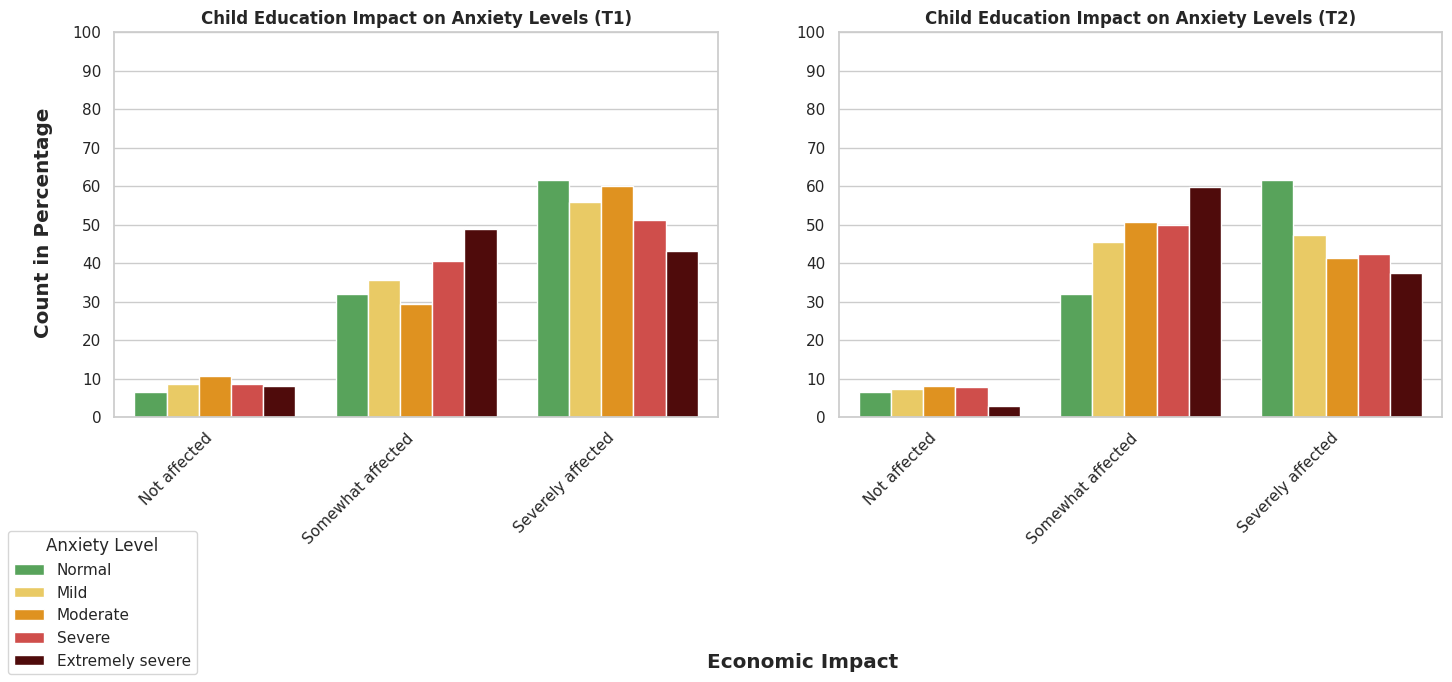

In [ ]:
severity_order = ['Normal','Mild','Moderate','Severe','Extremely severe']
palette = {
    'Normal': '#4caf50',            # green
    'Mild': '#ffd54f',              # yellow
    'Moderate': '#ff9800',          # orange
    'Severe': '#e53935',            # red
    'Extremely severe': '#5a0000'   # maroon
}

fig,axes = plt.subplots(1,2, figsize=(16,5))

sns.barplot(data=percent_melted_t1, x='education_of_children T1',  y='Count in Percentage', hue='anxiety_level T1', palette=palette, ax=axes[0])
axes[0].set_title("Child Education Impact on Anxiety Levels (T1)", fontweight='bold')
axes[0].set_yticks(np.linspace(0, 100, 11))

sns.barplot(data=percent_melted_t2, x='education_of_children T2',  y='Count in Percentage', hue='anxiety_level T2', palette=palette, ax=axes[1])
axes[1].set_title("Child Education Impact on Anxiety Levels (T2)", fontweight='bold')
axes[1].set_yticks(np.linspace(0, 100, 11))

fig.supxlabel("Economic Impact", fontweight='bold', y=-0.40)   # centered
fig.supylabel("Count in Percentage", fontweight='bold')
fig.subplots_adjust(left=0.07)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for label in ax.get_xticklabels():
      label.set_horizontalalignment('right')

# getting the information about the legend
handles, labels = axes[0].get_legend_handles_labels()

# remove legends from subplots
axes[0].legend_.remove()
axes[1].legend_.remove()

# creating global legend
fig.legend(handles, labels, title="Anxiety Level", loc="lower left")

plt.show()

**Conclusion:**
* The results suggest that individuals from families where children's education did worsen were more likely to develop some level of anxiety. This trend showed up in both phases.
* Thus, children's education appears to be an important factor contributing to the development of anxiety among individuals.

###**Education of children V/s Stress Level:**  

In [ ]:
order1 = ['Normal','Mild','Moderate','Severe','Extremely severe']
order2 = ['Not affected', 'Somewhat affected', 'Severely affected']

table_edu_vs_strT1 = pd.crosstab(mh['stress_level T1'], mh['education_of_children T1']).reindex(order1).reindex(order2, axis=1)
percent_table_edu_vs_strT1 = table_edu_vs_strT1.div(table_edu_vs_strT1.sum(axis=1), axis=0) * 100
percent_melted_t1 = percent_table_edu_vs_strT1.reset_index().melt(id_vars='stress_level T1', value_vars=order2, value_name='Count in Percentage')

table_edu_vs_strT2 = pd.crosstab(mh['stress_level T2'], mh['education_of_children T2']).reindex(order1).reindex(order2, axis=1)
percent_table_edu_vs_strT2 = table_edu_vs_strT2.div(table_edu_vs_strT2.sum(axis=1), axis=0) * 100
percent_melted_t2 = percent_table_edu_vs_strT2.reset_index().melt(id_vars='stress_level T2', value_vars=order2, value_name='Count in Percentage')

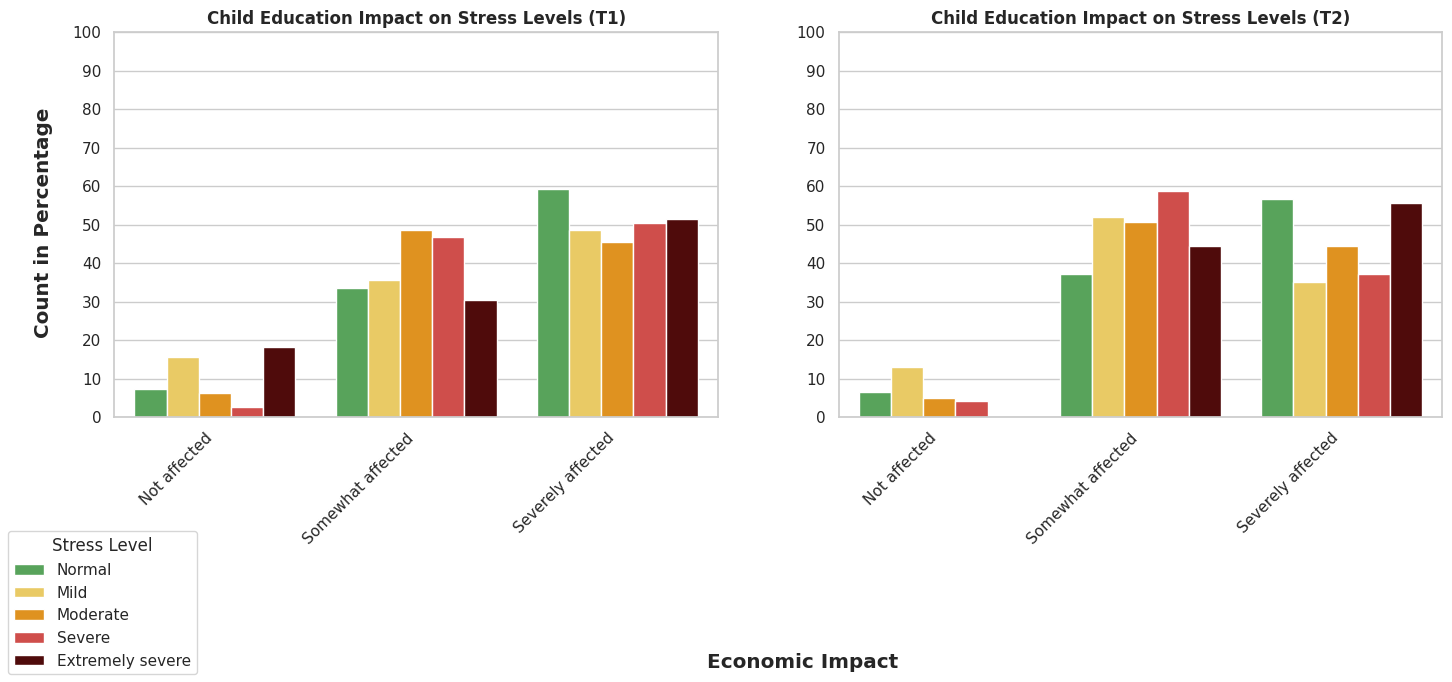

In [ ]:
severity_order = ['Normal','Mild','Moderate','Severe','Extremely severe']
palette = {
    'Normal': '#4caf50',            # green
    'Mild': '#ffd54f',              # yellow
    'Moderate': '#ff9800',          # orange
    'Severe': '#e53935',            # red
    'Extremely severe': '#5a0000'   # maroon
}

fig,axes = plt.subplots(1,2, figsize=(16,5))

sns.barplot(data=percent_melted_t1, x='education_of_children T1',  y='Count in Percentage', hue='stress_level T1', palette=palette, ax=axes[0])
axes[0].set_title("Child Education Impact on Stress Levels (T1)", fontweight='bold')
axes[0].set_yticks(np.linspace(0, 100, 11))

sns.barplot(data=percent_melted_t2, x='education_of_children T2',  y='Count in Percentage', hue='stress_level T2', palette=palette, ax=axes[1])
axes[1].set_title("Child Education Impact on Stress Levels (T2)", fontweight='bold')
axes[1].set_yticks(np.linspace(0, 100, 11))

fig.supxlabel("Economic Impact", fontweight='bold', y=-0.40)   # centered
fig.supylabel("Count in Percentage", fontweight='bold')
fig.subplots_adjust(left=0.07)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for label in ax.get_xticklabels():
      label.set_horizontalalignment('right')

# getting the information about the legend
handles, labels = axes[0].get_legend_handles_labels()

# remove legends from subplots
axes[0].legend_.remove()
axes[1].legend_.remove()

# creating global legend
fig.legend(handles, labels, title="Stress Level", loc="lower left")

plt.show()

**Conclusion:**
* The results suggest that individuals from families where children's education did worsen were more likely to develop some level of stress. This trend showed up in both phases.
* Thus, children's education appears to be an important factor contributing to the development of stress among individuals.

##**`Major Conclusion:`**
**The overall comparison indicates that the status of children's education is a significant factor associated with the development of depression, anxiety, and stress among individuals, thereby influencing overall mental health. Furthermore, the levels of depression, anxiety, and stress appear to be positively correlated with the severity of disruptions in children's education.**

###**Respondent's leisure time comparison over both phase:**

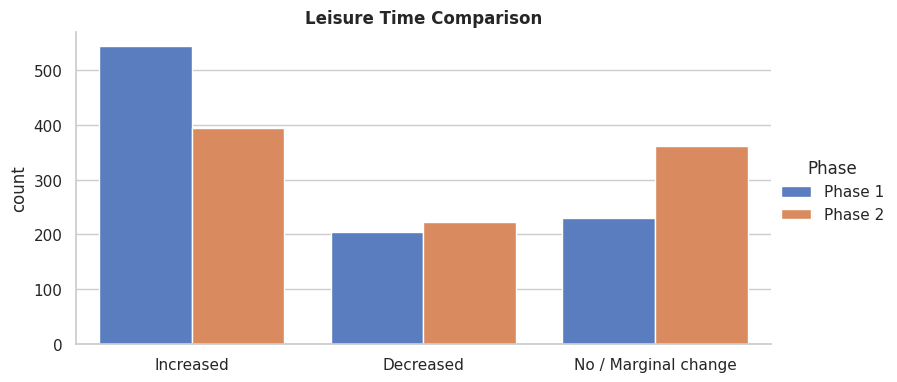

In [ ]:
leisuretimemh_melt = mh.melt(value_vars=['leisure_time T1','leisure_time T2'], var_name='Phase', value_name='leisuretime')
mh_melt['Phase'] = mh_melt['Phase'].replace({'leisure_time T1':'Phase 1', 'leisure_time T2':'Phase 2'})
sns.catplot(data=mh_melt, x='leisuretime', hue='Phase', kind='count', height=4, aspect=2)
plt.title('Leisure Time Comparison', fontweight='bold')
plt.xlabel('')   # remove bottom label
plt.show()

####
* This shows that there was a potential increment in leisure time in phase 1 as compared to phase 2

**Assumption->**
However, during Phase 2, families experiencing economic hardship may have had a greater tendency to enter the workforce directly, thereby leading to a decline in leisure time.

###**Respondent's families covid case comparison over both phase:**

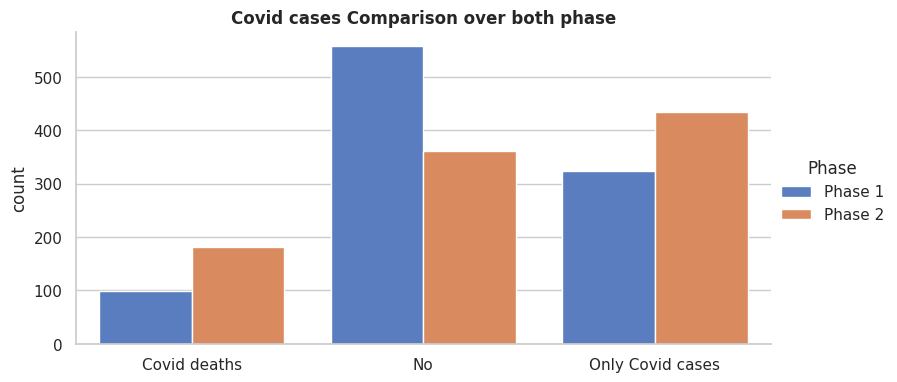

In [ ]:
mh_melt = mh.melt(value_vars=['covid_case T1','covid_case T2'], var_name='Phase', value_name='covidcase')
mh_melt['Phase'] = mh_melt['Phase'].replace({'covid_case T1':'Phase 1', 'covid_case T2':'Phase 2'})
sns.catplot(data=mh_melt, x='covidcase', hue='Phase', kind='count', height=4, aspect=2)
plt.title('Covid cases Comparison over both phase', fontweight='bold')
plt.xlabel('')
plt.show()

* Less cases of covid deaths as compared to covid affected
* Significant incremenet in both covid deaths and covid cases in phase 2

**Assumption->** Respondents whose families are affected by covid somehow may have a higher chance of suffering from depression/anxiety/stress

##**Does the covid case/death in the family made any impact on respondent's mental health?**  

###**Covid case V/s Depression rate:**

In [ ]:
mh

Loading ITables v2.7.0 from the internet... (need help?)


In [ ]:
order1 = ['Normal','Mild','Moderate','Severe','Extremely severe']
order2 = ['No', 'Only Covid cases', 'Covid deaths']

covid_vs_depT1 = pd.crosstab(mh['depression_level T1'], mh['covid_case T1']).reindex(order1).reindex(order2, axis=1)
percent_covid_vs_depT1 = covid_vs_depT1.div(covid_vs_depT1.sum(axis=1), axis=0) * 100
percent_melted_t1 = percent_covid_vs_depT1.reset_index().melt(id_vars='depression_level T1', value_vars=order2, value_name='Count in Percentage')

covid_vs_depT2 = pd.crosstab(mh['depression_level T2'], mh['covid_case T2']).reindex(order1).reindex(order2, axis=1)
percent_covid_vs_depT2 = covid_vs_depT2.div(covid_vs_depT2.sum(axis=1), axis=0) * 100
percent_melted_t2 = percent_covid_vs_depT2.reset_index().melt(id_vars='depression_level T2', value_vars=order2, value_name='Count in Percentage')

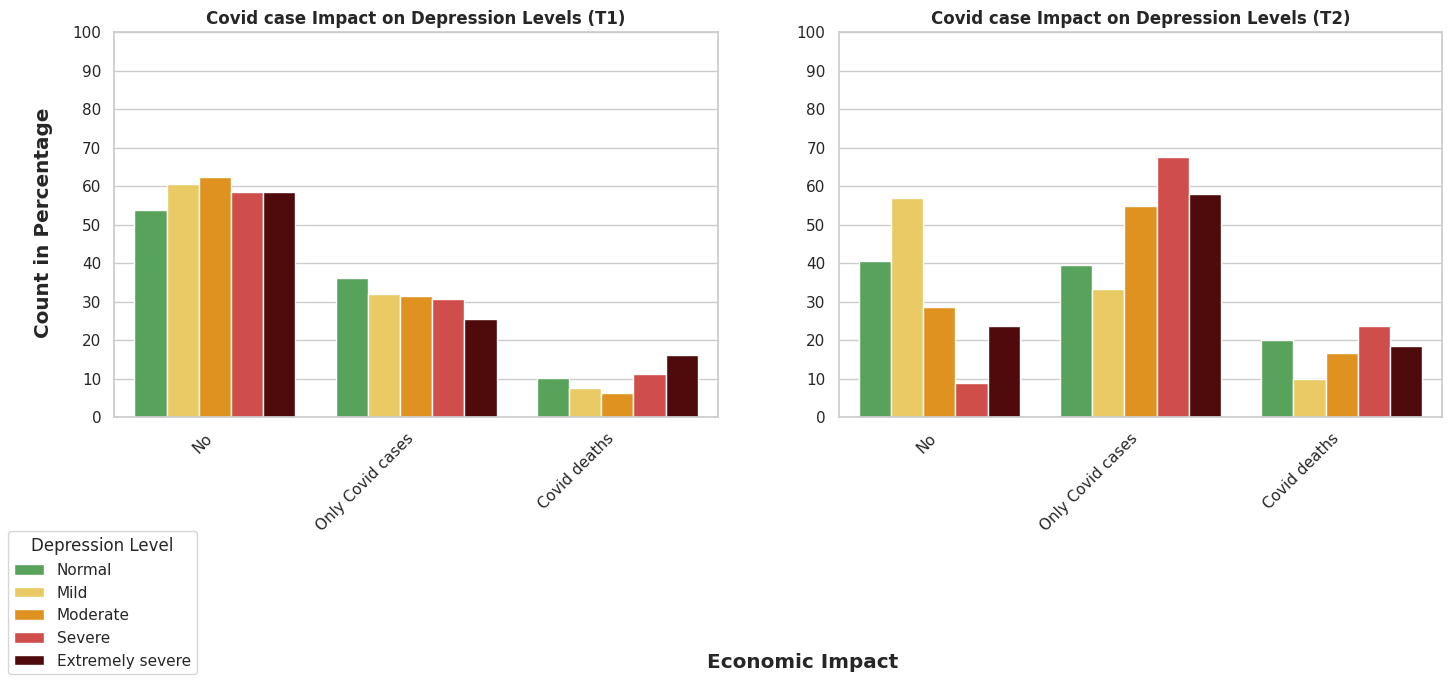

In [ ]:
severity_order = ['Normal','Mild','Moderate','Severe','Extremely severe']
palette = {
    'Normal': '#4caf50',            # green
    'Mild': '#ffd54f',              # yellow
    'Moderate': '#ff9800',          # orange
    'Severe': '#e53935',            # red
    'Extremely severe': '#5a0000'   # maroon
}

fig,axes = plt.subplots(1,2, figsize=(16,5))

sns.barplot(data=percent_melted_t1, x='covid_case T1', y='Count in Percentage', hue='depression_level T1', palette=palette, ax=axes[0])
axes[0].set_title("Covid case Impact on Depression Levels (T1)", fontweight='bold')
axes[0].set_yticks(np.linspace(0, 100, 11))

sns.barplot(data=percent_melted_t2, x='covid_case T2', y='Count in Percentage', hue='depression_level T2', palette=palette, ax=axes[1])
axes[1].set_title("Covid case Impact on Depression Levels (T2)", fontweight='bold')
axes[1].set_yticks(np.linspace(0, 100, 11))

fig.supxlabel("Economic Impact", fontweight='bold', y=-0.40)   # centered
fig.supylabel("Count in Percentage", fontweight='bold')
fig.subplots_adjust(left=0.07)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for label in ax.get_xticklabels():
      label.set_horizontalalignment('right')

# getting the information about the legend
handles, labels = axes[0].get_legend_handles_labels()

# remove legends from subplots
axes[0].legend_.remove()
axes[1].legend_.remove()

# creating global legend
fig.legend(handles, labels, title="Depression Level", loc="lower left")

plt.show()

**Conclusion:**
* The results indicate that 60% of respondents experiencing severe or extremely severe depression belonged to families where no COVID-19 cases or deaths were reported during Phase 1.
* However, in Phase 2, severe depression was more frequently reported among respondents whose families experienced COVID-19 cases.

###**Covid case V/s Anxiety levels:**

In [ ]:
order1 = ['Normal','Mild','Moderate','Severe','Extremely severe']
order2 = ['No', 'Only Covid cases', 'Covid deaths']

covid_vs_anxT1 = pd.crosstab(mh['anxiety_level T1'], mh['covid_case T1']).reindex(order1).reindex(order2, axis=1)
percent_covid_vs_anxT1 = covid_vs_anxT1.div(covid_vs_anxT1.sum(axis=1), axis=0) * 100
percent_melted_t1 = percent_covid_vs_anxT1.reset_index().melt(id_vars='anxiety_level T1', value_vars=order2, value_name='Count in Percentage')

covid_vs_anxT2 = pd.crosstab(mh['anxiety_level T2'], mh['covid_case T2']).reindex(order1).reindex(order2, axis=1)
percent_covid_vs_anxT2 = covid_vs_anxT2.div(covid_vs_anxT2.sum(axis=1), axis=0) * 100
percent_melted_t2 = percent_covid_vs_anxT2.reset_index().melt(id_vars='anxiety_level T2', value_vars=order2, value_name='Count in Percentage')

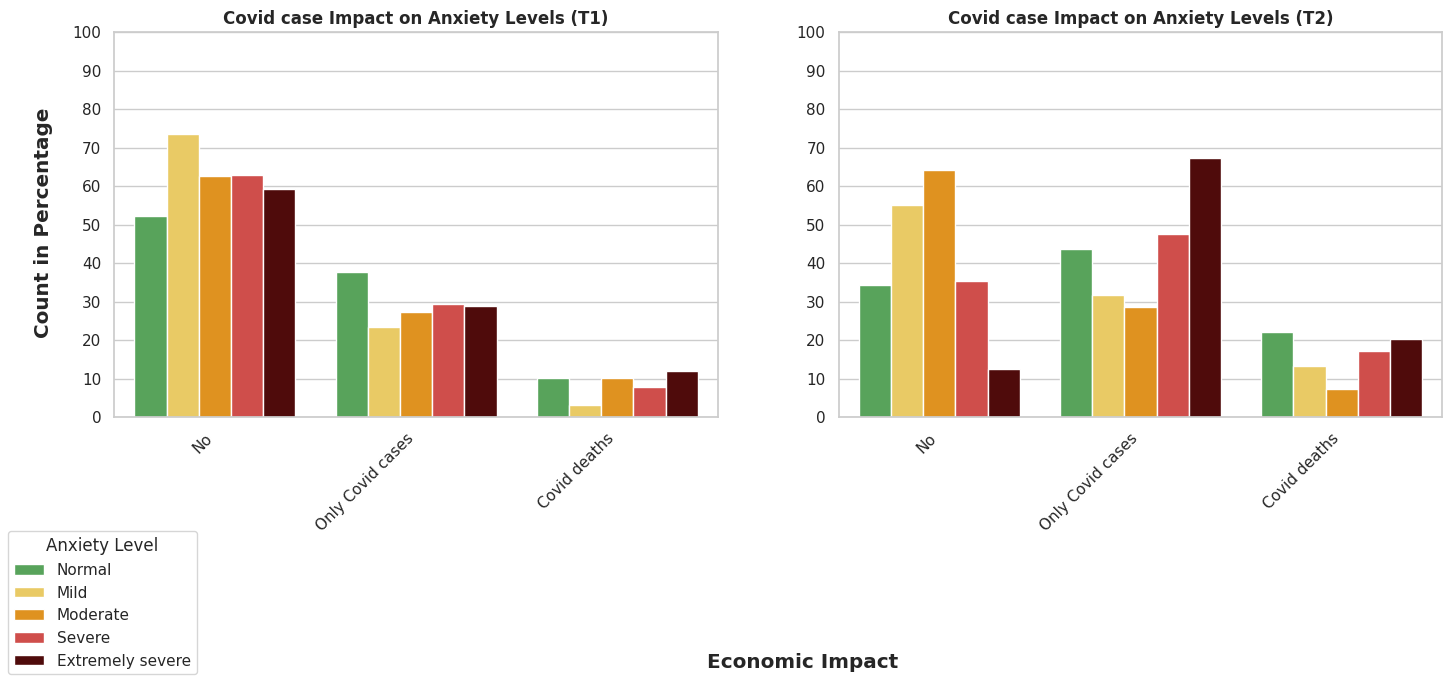

In [ ]:
severity_order = ['Normal','Mild','Moderate','Severe','Extremely severe']
palette = {
    'Normal': '#4caf50',            # green
    'Mild': '#ffd54f',              # yellow
    'Moderate': '#ff9800',          # orange
    'Severe': '#e53935',            # red
    'Extremely severe': '#5a0000'   # maroon
}

fig,axes = plt.subplots(1,2, figsize=(16,5))

sns.barplot(data=percent_melted_t1, x='covid_case T1', y='Count in Percentage', hue='anxiety_level T1', palette=palette, ax=axes[0])
axes[0].set_title("Covid case Impact on Anxiety Levels (T1)", fontweight='bold')
axes[0].set_yticks(np.linspace(0, 100, 11))

sns.barplot(data=percent_melted_t2, x='covid_case T2', y='Count in Percentage', hue='anxiety_level T2', palette=palette, ax=axes[1])
axes[1].set_title("Covid case Impact on Anxiety Levels (T2)", fontweight='bold')
axes[1].set_yticks(np.linspace(0, 100, 11))

fig.supxlabel("Economic Impact", fontweight='bold', y=-0.40)   # centered
fig.supylabel("Count in Percentage", fontweight='bold')
fig.subplots_adjust(left=0.07)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for label in ax.get_xticklabels():
      label.set_horizontalalignment('right')

# getting the information about the legend
handles, labels = axes[0].get_legend_handles_labels()

# remove legends from subplots
axes[0].legend_.remove()
axes[1].legend_.remove()

# creating global legend
fig.legend(handles, labels, title="Anxiety Level", loc="lower left")

plt.show()

###**Covid case V/s Stress level:**

In [ ]:
order1 = ['Normal','Mild','Moderate','Severe','Extremely severe']
order2 = ['No', 'Only Covid cases', 'Covid deaths']

covid_vs_strT1 = pd.crosstab(mh['stress_level T1'], mh['covid_case T1']).reindex(order1).reindex(order2, axis=1)
percent_covid_vs_strT1 = covid_vs_strT1.div(covid_vs_strT1.sum(axis=1), axis=0) * 100
percent_melted_t1 = percent_covid_vs_strT1.reset_index().melt(id_vars='stress_level T1', value_vars=order2, value_name='Count in Percentage')

covid_vs_strT2 = pd.crosstab(mh['stress_level T2'], mh['covid_case T2']).reindex(order1).reindex(order2, axis=1)
percent_covid_vs_strT2 = covid_vs_strT2.div(covid_vs_strT2.sum(axis=1), axis=0) * 100
percent_melted_t2 = percent_covid_vs_strT2.reset_index().melt(id_vars='stress_level T2', value_vars=order2, value_name='Count in Percentage')

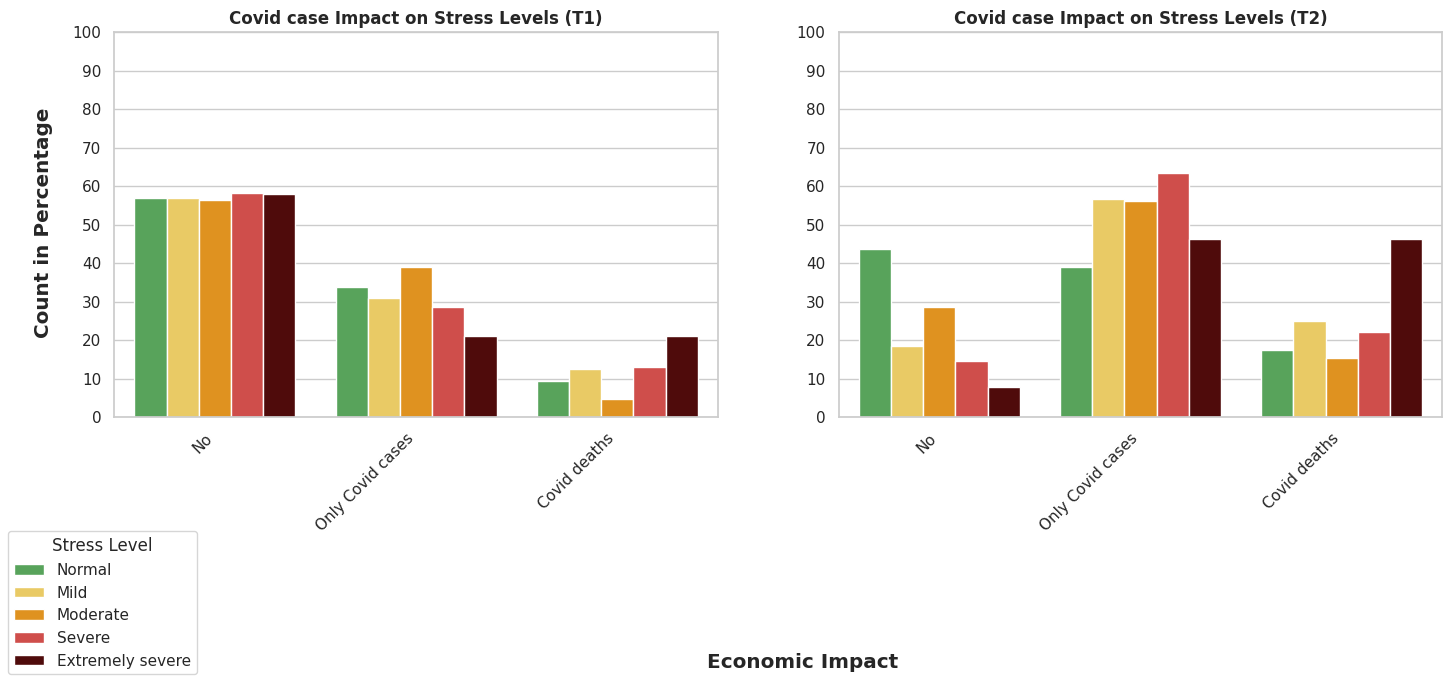

In [ ]:
severity_order = ['Normal','Mild','Moderate','Severe','Extremely severe']
palette = {
    'Normal': '#4caf50',            # green
    'Mild': '#ffd54f',              # yellow
    'Moderate': '#ff9800',          # orange
    'Severe': '#e53935',            # red
    'Extremely severe': '#5a0000'   # maroon
}

fig,axes = plt.subplots(1,2, figsize=(16,5))

sns.barplot(data=percent_melted_t1, x='covid_case T1', y='Count in Percentage', hue='stress_level T1', palette=palette, ax=axes[0])
axes[0].set_title("Covid case Impact on Stress Levels (T1)", fontweight='bold')
axes[0].set_yticks(np.linspace(0, 100, 11))

sns.barplot(data=percent_melted_t2, x='covid_case T2', y='Count in Percentage', hue='stress_level T2', palette=palette, ax=axes[1])
axes[1].set_title("Covid case Impact on Stress Levels (T2)", fontweight='bold')
axes[1].set_yticks(np.linspace(0, 100, 11))

fig.supxlabel("Economic Impact", fontweight='bold', y=-0.40)   # centered
fig.supylabel("Count in Percentage", fontweight='bold')
fig.subplots_adjust(left=0.07)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for label in ax.get_xticklabels():
      label.set_horizontalalignment('right')

# getting the information about the legend
handles, labels = axes[0].get_legend_handles_labels()

# remove legends from subplots
axes[0].legend_.remove()
axes[1].legend_.remove()

# creating global legend
fig.legend(handles, labels, title="Stress Level", loc="lower left")

plt.show()

In [ ]:
mh

Loading ITables v2.7.1 from the internet... (need help?)


###**Age Group V/s Depression, Anxiety, Stress Level:**

In [ ]:
bins = range(0, 101, 10)   # 0–10, 10–20, 20–30...
mh['age_group'] = pd.cut(mh['age'], bins=bins)

In [ ]:
agedep = pd.crosstab( mh['age_group'], mh['relative_dep'],normalize='index') * 100
ageanx = pd.crosstab( mh['age_group'], mh['relative_anx'],normalize='index') * 100
agestr = pd.crosstab( mh['age_group'], mh['relative_stress'],normalize='index') * 100

/tmp/ipykernel_160/1676886683.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(title="-Survey conducted among individuals aged 20–60\n"


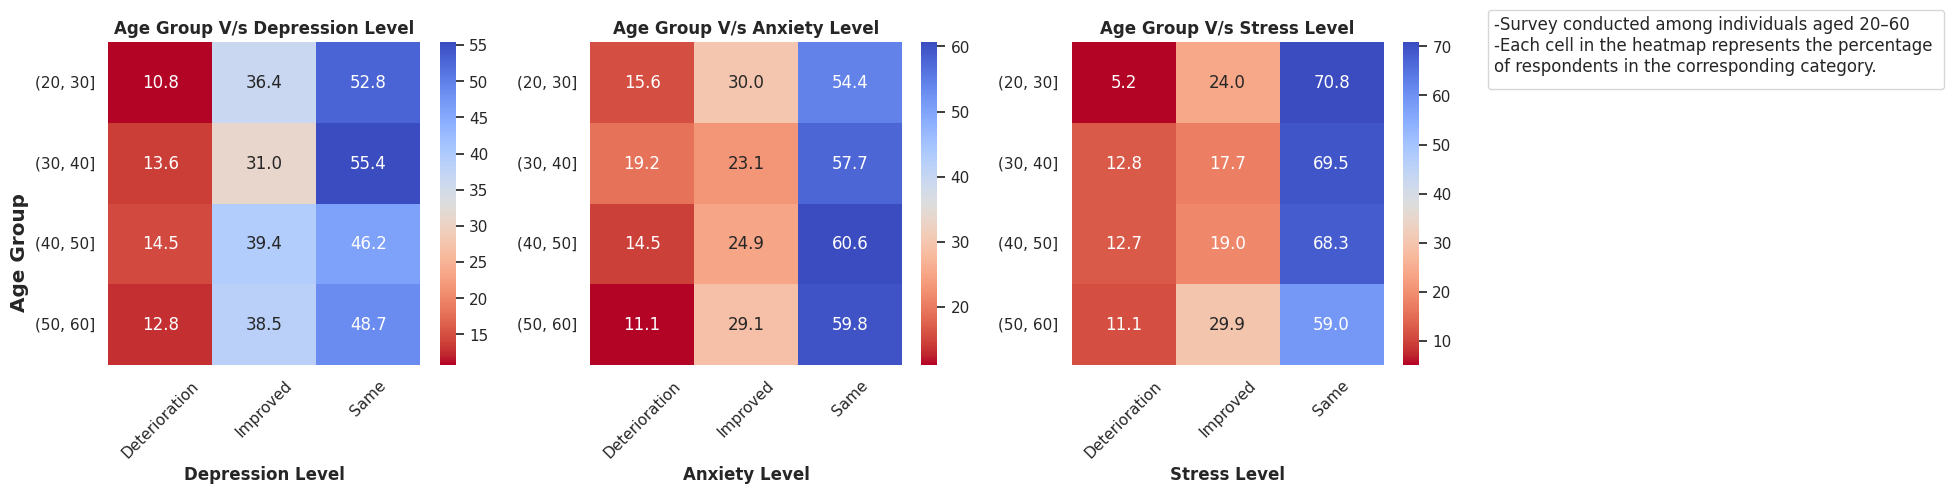

In [ ]:
fig,axes = plt.subplots(1, 3, figsize=(15,5))
sns.heatmap(agedep, annot=True, fmt=".1f", cmap="coolwarm_r", ax=axes[0])
sns.heatmap(ageanx, annot=True, fmt=".1f", cmap="coolwarm_r", ax=axes[1])
sns.heatmap(agestr, annot=True, fmt=".1f", cmap="coolwarm_r", ax=axes[2])

axes[0].set_xlabel("Depression Level",fontweight='bold')
axes[1].set_xlabel("Anxiety Level",fontweight='bold')
axes[2].set_xlabel("Stress Level",fontweight='bold')

# Adjusting titles for individual subplots
axes[0].set_title("Age Group V/s Depression Level", fontweight='bold')
axes[1].set_title("Age Group V/s Anxiety Level", fontweight='bold')
axes[2].set_title("Age Group V/s Stress Level", fontweight='bold')

fig.supylabel("Age Group", fontweight='bold')
# Rotating y-tick labels for all subplots
for ax in axes:
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('') # Remove individual y-labels as we have a supy-label

fig.legend(title="-Survey conducted among individuals aged 20–60\n"
    "-Each cell in the heatmap represents the percentage \nof respondents in the corresponding category.",bbox_to_anchor=(1, 1),loc='upper left')
plt.tight_layout()
plt.show()

In [7]:
mh

Loading ITables v2.7.3 from the internet... (need help?)


### **Correlation between depression, stress and anxiety in phase 1**

<Axes: >

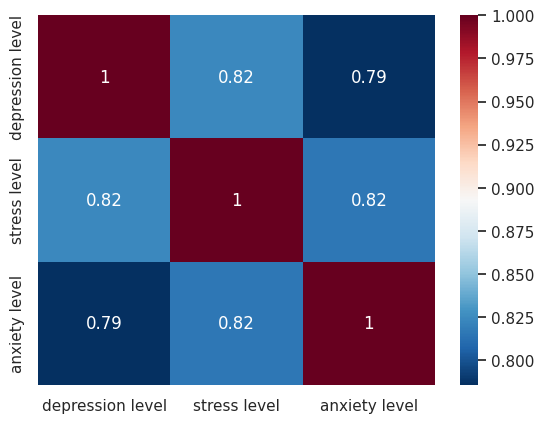

In [21]:
order = {'Normal': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3, 'Extremely severe': 4}

mh['depression level'] = mh['depression_level T1'].map(order)
mh['stress level'] = mh['stress_level T1'].map(order)
mh['anxiety level'] = mh['anxiety_level T1'].map(order)
sns.heatmap(mh[['depression level','stress level','anxiety level']].corr(method='spearman'), annot=True, cmap='RdBu_r')

####
First we converted categorical severity levels → numbers. This is called ordinal encoding.

Why? Because our data consists of is ordered categories, not random categories. So Extremely Severe > Severe > Moderate > Mild > Normal. This means we can treat them as ranked data, not exact measurements.

Why we used spearman corr.?
Because it measures whether two variables increase/decrease together in rank.NOT exact values — only order consistency.

`Understanding with an Example:`

Imagine 3 people:
| Person | Depression   | Stress       |
| ------ | ------------ | ------------ |
| A      | Mild (1)     | Mild (1)     |
| B      | Moderate (2) | Moderate (2) |
| C      | Severe (3)   | Severe (3)   |

This shows perfect increasing trend => correlation = +1

| Person | Depression   | Stress       |
| ------ | ------------ | ------------ |
| A      | Mild (1)     | Severe (3)   |
| B      | Moderate (2) | Mild (1)     |
| C      | Severe (3)   | Moderate (2) |

Now in this case there is order mismatch => lower correlation

Overall,
correlation coefficient ~ 1 → perfectly increases together

~ 0 → no relationship

~ -1 → one increases, other decreases



###**Insights:**

Depression ↔ Stress = 0.82

Stress ↔ Anxiety = 0.82

Depression ↔ Anxiety = 0.79

This suggests that the all three variables are strongly positively correlated.

`Individuals experiencing higher severity in one mental health condition are highly likely to experience higher severity in the others.`

### **Correlation between depression, stress and anxiety in phase 2**

<Axes: >

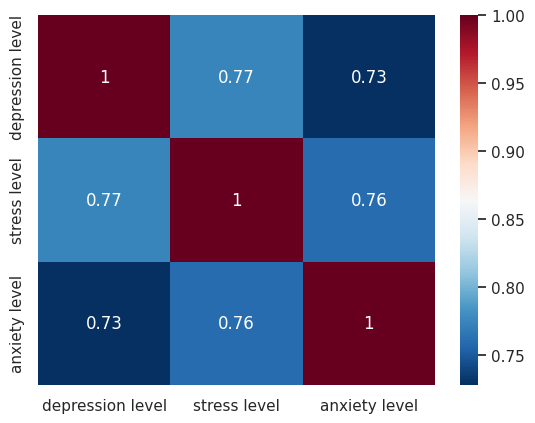

In [18]:
order = {'Normal': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3, 'Extremely severe': 4}

mh['depression level'] = mh['depression_level T2'].map(order)
mh['stress level'] = mh['stress_level T2'].map(order)
mh['anxiety level'] = mh['anxiety_level T2'].map(order)
sns.heatmap(mh[['depression level','stress level','anxiety level']].corr(method='spearman'), annot=True, cmap='RdBu_r')

###**Insights:**

Depression ↔ Stress = 0.77

Stress ↔ Anxiety = 0.76

Depression ↔ Anxiety = 0.73

This suggests that the all three variables are strongly positively correlated.

`This indicates that individuals with higher severity in one condition are highly likely to exhibit higher severity in the others, suggesting a closely interconnected mental health pattern.`

###**Comparison of Family Members Affected by Hypertension, Blood-pressure, Diabetes, or Cancer Between Phase 1 and Phase 2:**

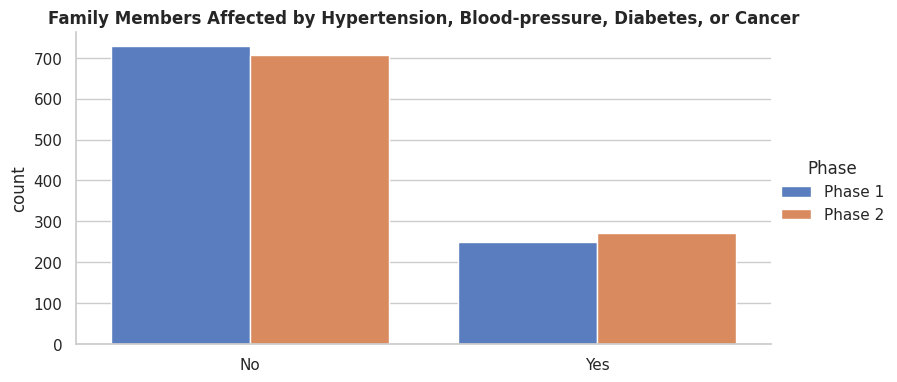

In [ ]:
mh_melt = mh.melt(value_vars=['fam_mem_suff_hyp-tens/bp/dbts/canc T1','fam_mem_suff_hyp-tens/bp/dbts/canc T2'], var_name='Phase', value_name='h')
mh_melt['Phase'] = mh_melt['Phase'].replace({'fam_mem_suff_hyp-tens/bp/dbts/canc T1':'Phase 1', 'fam_mem_suff_hyp-tens/bp/dbts/canc T2':'Phase 2'})
sns.catplot(data=mh_melt, x='h', hue='Phase', kind='count', height=4, aspect=2)
plt.title('Family Members Affected by Hypertension, Blood-pressure, Diabetes, or Cancer', fontweight='bold')
plt.xlabel('')
plt.show()


* in most cases, family members who were suffering from these diseases had developed them prior to the COVID-19 pandemic.

**Assumption->** Although it could be possible that this factor also contributed in the mental health of the respondent.